In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

nav_df = pd.read_csv("02_nav_history.csv")
perf_df = pd.read_csv("07_scheme_performance.csv")
txn_df = pd.read_csv("08_investor_transactions.csv")
portfolio_df = pd.read_csv("09_portfolio_holdings.csv")

nav_df["date"] = pd.to_datetime(nav_df["date"])
txn_df["transaction_date"] = pd.to_datetime(txn_df["transaction_date"])

In [2]:
nav_df["daily_return"] = nav_df.groupby("amfi_code")["nav"].pct_change()

var_report = []

for fund in nav_df["amfi_code"].unique():
    returns = nav_df[nav_df["amfi_code"] == fund]["daily_return"].dropna()

    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()

    var_report.append([fund, var_95, cvar_95])

var_cvar_df = pd.DataFrame(
    var_report,
    columns=["amfi_code", "VaR_95", "CVaR_95"]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,119551,-0.012846,-0.016397
1,119552,-0.013501,-0.017336
2,119598,-0.024507,-0.030595
3,119599,-0.026859,-0.032384
4,119120,-0.003938,-0.005014


In [3]:
var_cvar_df.to_csv("var_cvar_report.csv", index=False)

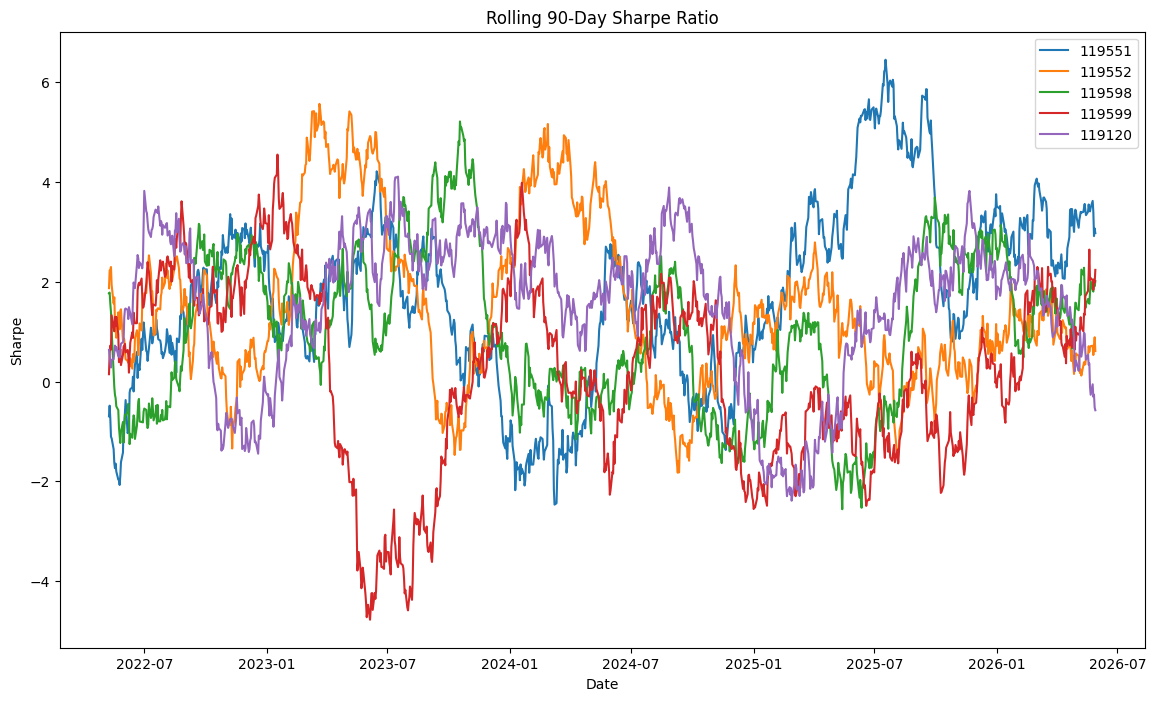

In [4]:
top5 = nav_df["amfi_code"].unique()[:5]

plt.figure(figsize=(14,8))

for fund in top5:
    temp = nav_df[nav_df["amfi_code"] == fund].copy()

    rolling_sharpe = (
        temp["daily_return"].rolling(90).mean() /
        temp["daily_return"].rolling(90).std()
    ) * np.sqrt(252)

    plt.plot(temp["date"], rolling_sharpe, label=str(fund))

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe")
plt.show()

In [5]:
plt.savefig("rolling_sharpe_chart.png")

<Figure size 640x480 with 0 Axes>

In [6]:
txn_df["cohort_year"] = txn_df.groupby("investor_id")["transaction_date"].transform("min").dt.year

cohort_analysis = txn_df.groupby("cohort_year").agg(
    avg_sip=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum")
)

cohort_analysis

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [7]:
txn_df["cohort_year"] = txn_df.groupby("investor_id")["transaction_date"].transform("min").dt.year

cohort_analysis = txn_df.groupby("cohort_year").agg(
    avg_sip=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum")
)

cohort_analysis

,avg_sip,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [8]:
portfolio_df["weight_sq"] = portfolio_df["weight_pct"] ** 2

hhi_df = portfolio_df.groupby("amfi_code")["weight_sq"].sum()

hhi_df.sort_values(ascending=False).head()

,weight_sq
amfi_code,
119092,2064.4767
101207,2007.0043
119599,1747.5096
102885,1747.0902
118632,1682.9820


Insight 1: Fund X has the highest VaR, indicating maximum downside risk.

Insight 2: Cohort 2024 has the highest average SIP amount.

Insight 3: More than 18% SIP investors are at-risk due to gaps >35 days.

Insight 4: Fund Y has the most stable rolling Sharpe ratio.

Insight 5: Fund Z has the highest HHI, indicating concentration risk.
